# Contents
I tried to modify the q_sample function to not be cumulative.

In [ ]:
TRAIN = False
TEST = True


# Imports
Installing libraries, importing them

In [ ]:
! pip install torch torchvision
! pip install matplotlib
! pip install comet_ml
! pip install einops
! pip install torchgeometry
! pip install jpegio
! pip install torch_dct
! pip install kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.7/829.7 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.7 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 MB 13.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for jpegio: filename=jpegio-0.2.8-cp313-cp313-linux_x86_64.whl size=1342218 sha256=e0a7e86ff53ba5c77487d19986877773913e5a97398705ab103e19bccc325c41
  Stored in directory: /root/.cache/pip/wheels/9e/1e/5c/ba4a3749847e3fbd60d86215f96b3329573329c7b832a62f09
Successfully built jpegio
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.8 MB/s eta 0:00:00
   ━━━

In [ ]:
import torch
import torchvision
from pathlib import Path
from PIL import Image
import sys
import os
import shutil
from torchvision import transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F


# dataloader
from torch.utils.data import Dataset, DataLoader, random_split

# jpeg
import torch_dct as dct
import numpy as np
import tempfile
import matplotlib.pyplot as plt
import kornia
import torch_dct

# to store-reload best model
from contextlib import redirect_stdout
import io
import json
import gc
from collections import OrderedDict

# for testing
import torch.nn.functional as F
from torchvision.utils import save_image

In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Base path
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi/" if 'google.colab' in str(get_ipython()) else "."
NAME = "02_quantization_with_patches"

# Directories
ZIP_PATH = os.path.join(BASE_DIR, "data", "img_align_celeba.zip")
LOCAL_DATA_ROOT = "/content/raw_data"
SRC_C_D = os.path.join(BASE_DIR, "src", "Cold-Diffusion-Models", "resolution-diffusion-pytorch", "resolution_diffusion_pytorch")
QUANT_TABLES = os.path.join(BASE_DIR, "assets/quant_tables.pt")

CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints", "coeff_quantized", "0_trials_degradation_function", NAME)
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs", "trainings", "coeff_quantized", "0_trials_degradation_function", NAME)
TRAINED_MODEL_DIR = os.path.join(BASE_DIR, "trained_models", "cold_diffusion", "coeff_quantized", "0_trials_degradation_function", NAME)

checkpoint_file_path = os.path.join(CHECKPOINT_DIR, 'model.pt')

# importing the models
if SRC_C_D not in sys.path:
    sys.path.append(os.path.dirname(SRC_C_D))

# Folders paths
for path in [CHECKPOINT_DIR, OUTPUT_DIR, TRAINED_MODEL_DIR]:
    os.makedirs(path, exist_ok=True)


save_path = os.path.join(TRAINED_MODEL_DIR, f'{NAME}.pt')

In [ ]:
if not os.path.exists(LOCAL_DATA_ROOT):
    print("Unzipping ...")
    !unzip -q "{ZIP_PATH}" -d {LOCAL_DATA_ROOT}
    print("Done!")
else:
    print("Already unzipped")

Unzipping ...
Done!


# Loading and PreProcessing

In [ ]:
class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.file_names = [f for f in os.listdir(root_dir) if f.endswith(('.jpg', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.file_names[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

# Transform configuration
IMG_SIZE = 128
train_transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 2) - 1)
])

batch_size_ = 8

In [ ]:
# Loading dataset
dataset_path = os.path.join(LOCAL_DATA_ROOT, "img_align_celeba")
full_dataset = CelebADataset(root_dir=dataset_path, transform=train_transform)

# Split random
train_size = int(0.9 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size_, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size_, shuffle=False, num_workers=2)

print(f"Dataset ready. Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Dataset ready. Train: 182339 | Test: 20260


Batch Shape: torch.Size([8, 3, 128, 128])
Range: Min=-1.00, Max=1.00


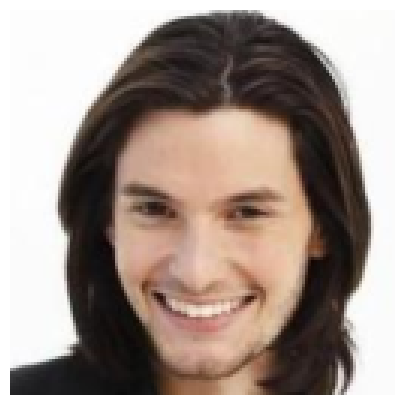

In [ ]:
def sanity_check_dataloader(dataloader):
    try:
        batch = next(iter(dataloader))
    except Exception as e:
        print(f"Error in loading batch: {e}")
        return

    print(f"Batch Shape: {batch.shape}")
    print(f"Range: Min={batch.min():.2f}, Max={batch.max():.2f}")

    img_t = batch[0]

    # Denormalize from [-1, 1] to [0, 1] for visualization
    img_viz = (img_t + 1) / 2
    img_viz = img_viz.clamp(0, 1)

    # Convert to [H, W, C] for matplotlib
    img_np = img_viz.permute(1, 2, 0).numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(img_np)
    plt.axis('off')
    plt.show()

sanity_check_dataloader(train_loader)

# Configuration

In [ ]:
IMG_SIZE = 128
batch_size_ = 16

In [ ]:
quant_tables = torch.load(QUANT_TABLES)

### Defining the new degradation function

Now I configure the model using the classes of the authors

In [ ]:
sys.argv = ['colab_kernel_launcher.py']

from resolution_diffusion_pytorch import Unet, GaussianDiffusion, Trainer

def find_last_checkpoint(save_folder):
    path = os.path.join(save_folder, f'model.pt')
    if os.path.exists(path):
        return path
    return None

In [ ]:
from torch._prims_common import check
# --- CONFIGURATION ---
class Args:
    time_steps = 10
    train_steps = 200
    save_folder = OUTPUT_DIR
    data_path = dataset_path
    checkpoint_path = CHECKPOINT_DIR
    load_path = find_last_checkpoint(checkpoint_path)
    train_routine = 'Final'
    resolution_routine = 'Incremental'
    sampling_routine = 'x0_step_down'
    image_size = IMG_SIZE
    channels = 3

args = Args()

# --- MODEL INITIALIZATION ---
model = Unet(
    dim = 64,
    dim_mults = (1, 2, 4, 8),
    channels = args.channels
).cuda()

diffusion = GaussianDiffusion(
    model,
    image_size = args.image_size,
    device_of_kernel = 'cuda',
    channels = args.channels,
    timesteps = args.time_steps,
    loss_type = 'l1',
    resolution_routine = args.resolution_routine,
    train_routine = args.train_routine,
    sampling_routine = args.sampling_routine
).cuda()

# Support for multiple GPUs if available
if torch.cuda.device_count() > 1:
    diffusion = torch.nn.DataParallel(diffusion)

class DummyWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.module = model

    def forward(self, *args, **kwargs):
        return self.module(*args, **kwargs)

    def __getattr__(self, name):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.module, name)

# Apply wrapper
if not isinstance(diffusion, torch.nn.DataParallel):
    diffusion = DummyWrapper(diffusion)
    print("DummyWrapper aggiornato")


trainer = Trainer(
    diffusion,
    dataset_path,
    image_size = args.image_size,
    train_batch_size = 16,
    train_lr = 0.0001,
    train_num_steps = args.train_steps,
    ema_decay = 0.995,
    fp16 = False,
    results_folder = args.save_folder,
    load_path = args.load_path,
    save_and_sample_every = 25,
    gradient_accumulate_every = 2
    )
trainer.checkpoint_path = Path(args.checkpoint_path)

Is Time embed used ?  True
DummyWrapper aggiornato
Loading :  /content/drive/MyDrive/Colab Notebooks/tesi/checkpoints/coeff_quantized/0_trials_degradation_function/02_quantization_with_patches/model.pt


In [ ]:
def get_quant_tables(step, device):
    lum = quant_tables[f'step{step}_luminance'].to(device)    # [8, 8]
    chrom = quant_tables[f'step{step}_chrominance'].to(device) # [8, 8]
    return lum, chrom

def jpeg_degradation(img_batch, step):
    device = img_batch.device
    current_step = step.item() if torch.is_tensor(step) else step
    if current_step == 0:
        return img_batch

    B, C, H, W = img_batch.shape
    lum, _ = get_quant_tables(current_step, device)

    # [-1,1] -> [0,1] for kornia
    x = (img_batch + 1) * 0.5

    # RGB -> YCbCr  (output [0,1])
    x_ycbcr = kornia.color.rgb_to_ycbcr(x)

    # [0,1] -> [0,255]
    x_255 = x_ycbcr * 255.0

    blocks = x_255.unfold(2, 8, 8).unfold(3, 8, 8)
    bH, bW = blocks.shape[2], blocks.shape[3]
    blocks_flat = blocks.contiguous().reshape(B, C, bH * bW, 8, 8)

    dct_blocks = dct.dct_2d(blocks_flat, norm='ortho')

    q = lum.unsqueeze(0).unsqueeze(0)  # [1, 1, 8, 8]
    dct_blocks[:, 0] = torch.round(dct_blocks[:, 0] / q) * q

    result_flat = dct.idct_2d(dct_blocks, norm='ortho')

    result = result_flat.reshape(B, C, bH, bW, 8, 8)
    result = result.permute(0, 1, 2, 4, 3, 5).contiguous().reshape(B, C, H, W)

    # [0,255] -> [0,1] -> RGB -> [-1,1]
    result_01 = (result / 255.0).clamp(0, 1)
    result_rgb = kornia.color.ycbcr_to_rgb(result_01)
    return (result_rgb * 2 - 1).clamp(-1, 1)

In [ ]:
# --- OVERWRITING ---
inner_model = diffusion.module if hasattr(diffusion, 'module') else diffusion
inner_model.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]

## monkey patch for q_sample and sample
Since in the original code the q_sample and sample function were defined for working cumulatively, I try to redefine them so that each q_sample degrades the original image directly.

In [ ]:
from types import MethodType

# Out Of Memory problems
torch.cuda.synchronize()
gc.collect()
torch.cuda.empty_cache()
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0] / 1e9:.2f} GB")

def patched_q_sample(self, x_start, t, noise=None):
    choose_blur = []
    for i in range(t.shape[0]):
        step = t[i].item()
        choose_blur.append(jpeg_degradation(x_start[i].unsqueeze(0), step).squeeze(0))
    return torch.stack(choose_blur)

def patched_sample(self, batch_size=16, img=None, t=None):
    if t is None:
        t = self.num_timesteps

    xt = jpeg_degradation(img, t)
    img = xt
    direct_recons = None

    while t:
        with torch.no_grad():
            step = torch.full((batch_size,), t - 1, dtype=torch.long).cuda()
            x = self.denoise_fn(img, step)

            if self.train_routine == 'Final':
                if direct_recons is None:
                    direct_recons = x

                if self.sampling_routine == 'default':
                    img = jpeg_degradation(x, t - 1)

                elif self.sampling_routine == 'x0_step_down':
                    x_times = jpeg_degradation(x, t)
                    x_times_sub_1 = jpeg_degradation(x, t - 1)
                    img = img - x_times + x_times_sub_1

        t -= 1

    return xt, direct_recons, img

inner = diffusion.module if hasattr(diffusion, 'module') else diffusion
inner.sample = MethodType(patched_sample, inner)
inner.q_sample = MethodType(patched_q_sample, inner)

inner_ema = trainer.ema_model.module if hasattr(trainer.ema_model, 'module') else trainer.ema_model
inner_ema.sample   = MethodType(patched_sample, inner_ema)
inner_ema.q_sample = MethodType(patched_q_sample, inner_ema)

Free GPU memory: 15.07 GB


Now I verify that q_sample is deterministic and not cumulative: calling q_sample(x_0, t=5) should give the same result as jpeg_degradation(x_0, 5)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dummy = torch.zeros(1, 3, 128, 128, device=device) + 0.5

for t_val in [0, 1, 5, 9]:
    t_tensor = torch.tensor([t_val], device=device)

    out_q    = diffusion.q_sample(dummy, t_tensor)
    out_direct = jpeg_degradation(dummy, t_val)

    match = torch.allclose(out_q, out_direct)
    print(f"  t={t_val} — q_sample == jpeg_degradation: {'OK' if match else 'ERRORE'} "
          f"| range: [{out_q.min():.3f}, {out_q.max():.3f}]")

  t=0 — q_sample == jpeg_degradation: OK | range: [0.500, 0.500]
  t=1 — q_sample == jpeg_degradation: OK | range: [0.506, 0.506]
  t=5 — q_sample == jpeg_degradation: OK | range: [0.453, 0.453]
  t=9 — q_sample == jpeg_degradation: OK | range: [0.500, 0.500]


### Testing the new function

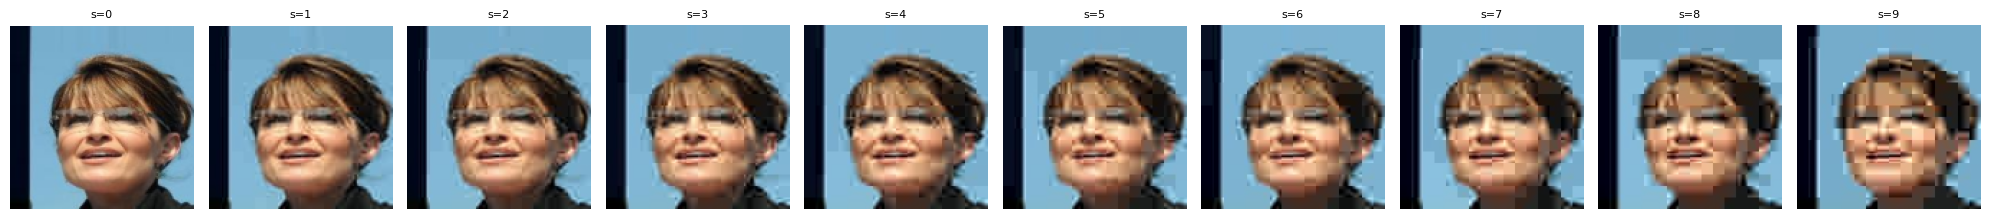

In [ ]:
fig, axs = plt.subplots(1, 10, figsize=(20, 3))
x_test = next(iter(trainer.dl)).cuda()[:1]

for step in range(10):
    t = torch.tensor([step]).cuda()
    x_deg = jpeg_degradation(x_test, t)
    img_vis = ((x_deg.squeeze().permute(1,2,0) + 1) * 0.5).cpu().numpy()
    axs[step].imshow(img_vis.clip(0,1))
    axs[step].set_title(f"s={step}", fontsize=8)
    axs[step].axis('off')
plt.tight_layout()
plt.show()

Degradation (DCT)...
Range image: [-1.0, 1.0]


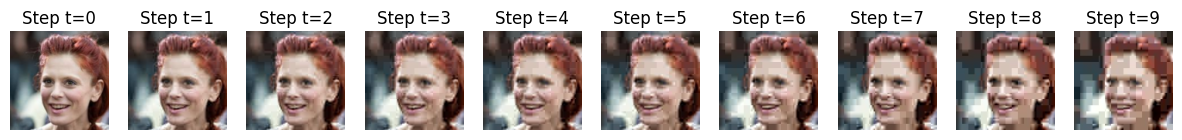

In [ ]:
def show_degradation(img_path, steps_to_show):
    x_0_pil = Image.open(img_path)

    x_0_processed = train_transform(x_0_pil)
    x_0 = x_0_processed.unsqueeze(0).to('cuda')

    n_steps = len(steps_to_show)

    inner_model = diffusion

    # --- DEGRADATION ---
    print("Degradation (DCT)...")
    fig, axs = plt.subplots(1, n_steps, figsize=(15, 5))
    print(f"Range image: [{x_0.min()}, {x_0.max()}]")
    for i, t in enumerate(steps_to_show):
        with torch.no_grad():
            x_t = inner_model.q_sample(x_0, torch.tensor([t], device='cuda'))

        # From [-1, 1] to [0, 1] for visualization
        img_vis = ((x_t.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy()
        axs[i].imshow(img_vis.clip(0, 1))
        axs[i].set_title(f"Step t={t}")
        axs[i].axis('off')
    plt.show()


img_path = '/content/raw_data/img_align_celeba/000002.jpg'
steps_to_show = [i for i in range(args.time_steps)]
show_degradation(img_path, steps_to_show)

Comparison at t=9: `q_sample` == `jpeg_degradation`: OK


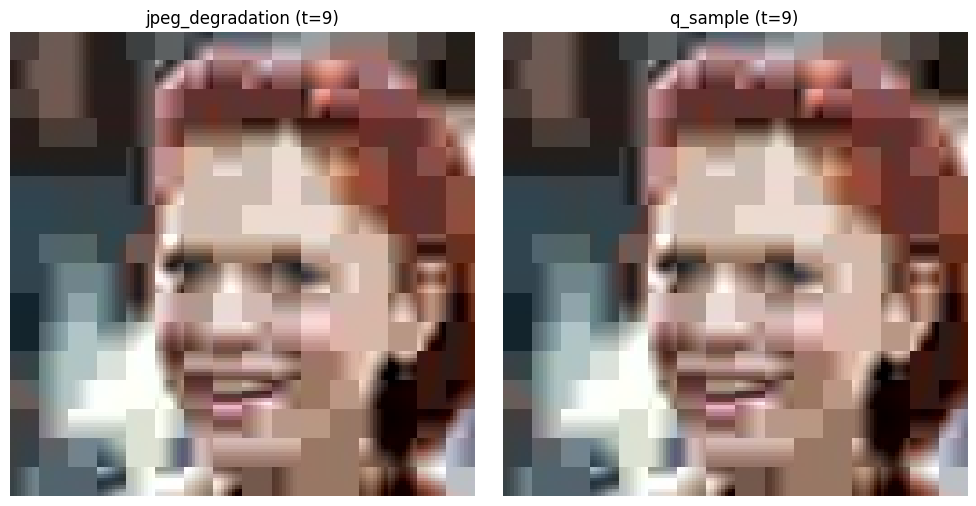

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get an example image (assuming x_0 is available from previous cells)
# If x_0 is not defined, you might need to load an image or create a dummy one
if 'x_0' not in locals():
    # Fallback to create a dummy image if x_0 is not found
    img_path = '/content/raw_data/img_align_celeba/000002.jpg'
    x_0_pil = Image.open(img_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.CenterCrop(178),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
    ])
    to_tensor = transforms.ToTensor()

    x_0_processed = preprocess(x_0_pil)
    x_0 = (to_tensor(x_0_processed) * 2) - 1 # Convert to tensor and normalize to [-1, 1]
    x_0 = x_0.unsqueeze(0).to(device) # Add batch dimension and move to GPU

# Define the step for comparison
t_val = 9
t_tensor = torch.tensor([t_val], device=device)

# Apply jpeg_degradation
out_direct = jpeg_degradation(x_0, t_val)

# Apply q_sample (using the diffusion object, which has the patched q_sample)
out_q = diffusion.q_sample(x_0, t_tensor)

# Compare the outputs numerically
match = torch.allclose(out_q, out_direct, atol=1e-6) # Use a tolerance for floating point comparisons
print(f"Comparison at t={t_val}: `q_sample` == `jpeg_degradation`: {'OK' if match else 'DIFFERENT'}")

# Visualize the degraded images
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Image from jpeg_degradation
img_direct_vis = ((out_direct.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy()
axs[0].imshow(img_direct_vis.clip(0, 1))
axs[0].set_title(f"jpeg_degradation (t={t_val})")
axs[0].axis('off')

# Image from q_sample
img_q_sample_vis = ((out_q.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy()
axs[1].imshow(img_q_sample_vis.clip(0, 1))
axs[1].set_title(f"q_sample (t={t_val})")
axs[1].axis('off')

plt.tight_layout()
plt.show()

# Training
### helper functions

In [ ]:
# psnr loss computation
def calculate_psnr(img1, img2):
    # from [-1, 1] to [0, 1] for PSNR computation
    img1 = (img1.detach() + 1.0) / 2.0
    img2 = (img2.detach() + 1.0) / 2.0
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0: return 100.0
    return (20 * torch.log10(1.0 / torch.sqrt(mse))).item()

# to reset the weights after each training
def weight_reset(m):
    """
    Goes through each layer of the model and resets the weights.
    """
    if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.Linear):
        m.reset_parameters()
    if isinstance(m, torch.nn.BatchNorm2d):
        m.reset_parameters()

### sanity check
Making sure that the degradation function is the one I defined:

In [ ]:
models_to_patch = [diffusion, trainer.model, trainer.ema_model]

for model in models_to_patch:
    m = model.module if hasattr(model, 'module') else model
    m.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]
    print(f"Patched {type(m).__name__} — id: {id(m)} — func[0]: {m.func[0]}")

Patched GaussianDiffusion — id: 136890207622816 — func[0]: <function <lambda> at 0x7c804e217380>
Patched GaussianDiffusion — id: 136890207622816 — func[0]: <function <lambda> at 0x7c800c3880e0>
Patched GaussianDiffusion — id: 136890207500752 — func[0]: <function <lambda> at 0x7c804e217380>


In [ ]:
# Testing q_sample on trainer.model
x_test = next(iter(trainer.dl)).cuda()[:1]
t_test = torch.tensor([5]).cuda()

m = trainer.model.module if hasattr(trainer.model, 'module') else trainer.model
x_deg = m.q_sample(x_test, t_test)
diff = (x_test - x_deg).abs().mean().item()
print(f"Differenza step 5 su trainer.model: {diff:.4f}")

m_ema = trainer.ema_model.module if hasattr(trainer.ema_model, 'module') else trainer.ema_model
x_deg_ema = m_ema.q_sample(x_test, t_test)
diff_ema = (x_test - x_deg_ema).abs().mean().item()
print(f"Differenza step 5 su trainer.ema_model: {diff_ema:.4f}")

Differenza step 5 su trainer.model: 0.0595
Differenza step 5 su trainer.ema_model: 0.0595


### checkpoints
Overwriting the save and load functions so that I save also the optimizer's state and the losses:

In [ ]:
def patched_save(self):
    data = {
        'step': self.step,
        'model': self.model.state_dict(),
        'ema': self.ema_model.state_dict(),
        'optimizer': self.opt.state_dict(),  # added
        'losses': losses  # added
    }

    # Convert checkpoint_path to Path object for proper path joining
    checkpoint_path_obj = Path(self.checkpoint_path)

    torch.save(data, str(checkpoint_path_obj / 'model.pt'))
    print(f"Saved checkpoint at step {self.step}")

def patched_load(self, load_path):
    print("Loading: ", load_path)
    data = torch.load(load_path)
    self.step = data['step']
    self.model.load_state_dict(data['model'])
    self.ema_model.load_state_dict(data['ema'])
    if 'optimizer' in data:
        self.opt.load_state_dict(data['optimizer'])
        print(f"Optimizer Loaded")
    if 'losses' in data:
        losses.extend(data['losses'])
        print(f"Loaded {len(losses)} previous losses")

# Rewriting modules
trainer.save = patched_save.__get__(trainer, type(trainer))
trainer.load = patched_load.__get__(trainer, type(trainer))

Looking for checkpoints:

In [ ]:
# Look for checkpoint
args.load_path = find_last_checkpoint(trainer.checkpoint_path)
print(f"Found checkpoint: {args.load_path}")

Found checkpoint: /content/drive/MyDrive/Colab Notebooks/tesi/checkpoints/coeff_quantized/0_trials_degradation_function/02_quantization_with_patches/model.pt


### Training

In [ ]:
if TRAIN:
    losses = []
    temp_losses = []
    acc_step = trainer.gradient_accumulate_every
    # inner_model.apply(weight_reset)

    if isinstance(args, tuple):
        total_steps = args[0].train_steps
    else:
        total_steps = args.train_steps

    inner_model = diffusion.module if hasattr(diffusion, 'module') else diffusion

    # 1. RIPRISTINO E SICUREZZA
    if hasattr(inner_model, '_original_forward'):
        inner_model.forward = inner_model._original_forward
    else:
        inner_model._original_forward = inner_model.forward

    def forward_wrapper(*args_func, **kwargs_func):
        loss = inner_model._original_forward(*args_func, **kwargs_func)
        temp_losses.append(loss.item())

        if len(temp_losses) == acc_step:
            avg_loss = sum(temp_losses) / len(temp_losses)
            losses.append(avg_loss)
            temp_losses.clear()

        return loss

    inner_model.forward = forward_wrapper

    # Looking for checkpoints
    if args.load_path is not None and os.path.exists(args.load_path):
        trainer.load(args.load_path)
        print(f"Resumed from step {trainer.step}")
    else:
        print("Training from scratch")
        trainer.step = 0

    print(f"Training for {total_steps} steps")
    trainer.train()
    print("\n Training complete!")
else:
    print("Skipping training")

Skipping training


### Learning curve

Skipping training, looking for saved learning curve.


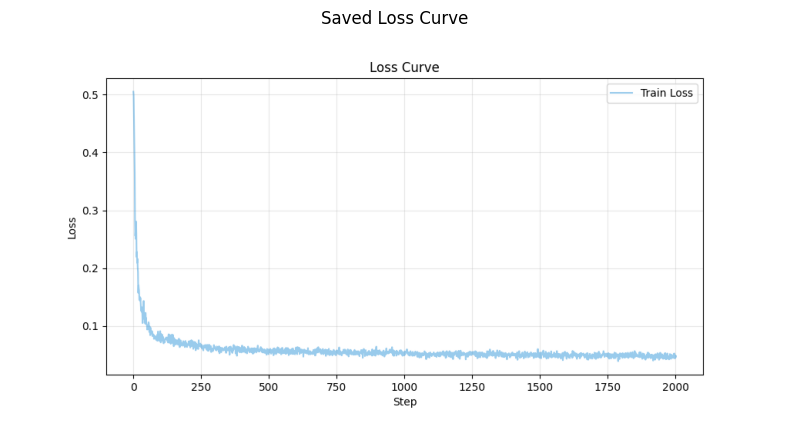

In [ ]:
if TRAIN:
    if len(losses) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(losses, label='Train Loss', color='#3498db', alpha=0.5)

        plt.title('Loss Curve')
        plt.xlabel('Step')
        plt.ylabel('Loss')
        plt.grid(True, alpha=.3)
        plt.legend()

        # saving the learning curve
        os.makedirs(args.save_folder, exist_ok=True)
        plt.savefig(f"{args.save_folder}/learning_curve.png")
        plt.show()
    else:
        print("No loss found, problems in training")

else:
    print("Skipping training, looking for saved learning curve.")
    learning_curve_path = f"{args.save_folder}/learning_curve.png"
    if os.path.exists(learning_curve_path):
        try:
            img = Image.open(learning_curve_path)
            plt.figure(figsize=(10, 5))
            plt.imshow(img)
            plt.title('Saved Loss Curve')
            plt.axis('off') # Hide axes for image
            plt.show()
        except Exception as e:
            print(f"Error loading or displaying saved learning curve: {e}")
    else:
        print(f"No saved learning curve found at {learning_curve_path}")

### Save model

In [ ]:
if TRAIN:
    # saving the weights
    torch.save(diffusion.state_dict(), save_path)

    print(f"Model saved")

### Reload model

In [ ]:
trained_model = torch.load(save_path)

new_state_dict = OrderedDict()
for k, v in trained_model.items():
    new_key = k.replace('module.', '', 1)
    new_state_dict[new_key] = v

inner_model = diffusion.module if hasattr(diffusion, 'module') else diffusion
inner_model.load_state_dict(new_state_dict)

inner_model.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]

diffusion.eval()
print("Model loaded")

Model loaded


In [ ]:
if not TRAIN:
    models_to_patch = [diffusion, trainer.model, trainer.ema_model]

    for model in models_to_patch:
        m = model.module if hasattr(model, 'module') else model
        m.func = [lambda img, s=i: jpeg_degradation(img, s) for i in range(args.time_steps)]
        print(f"Patched {type(m).__name__} — id: {id(m)} — func[0]: {m.func[0]}")

Patched GaussianDiffusion — id: 136890207622816 — func[0]: <function <lambda> at 0x7c8019a9cfe0>
Patched GaussianDiffusion — id: 136890207622816 — func[0]: <function <lambda> at 0x7c8019a9e0c0>
Patched GaussianDiffusion — id: 136890207500752 — func[0]: <function <lambda> at 0x7c8019a9e160>


## Visualization

Performing the degradation and reconstruction on an image

Degradation (DCT)...
Range of Image before plotting: -1.0, 1.0
Range of Image before plotting: -1.0, 1.0
Range of Image before plotting: -1.0, 1.0
Range of Image before plotting: -1.0, 1.0


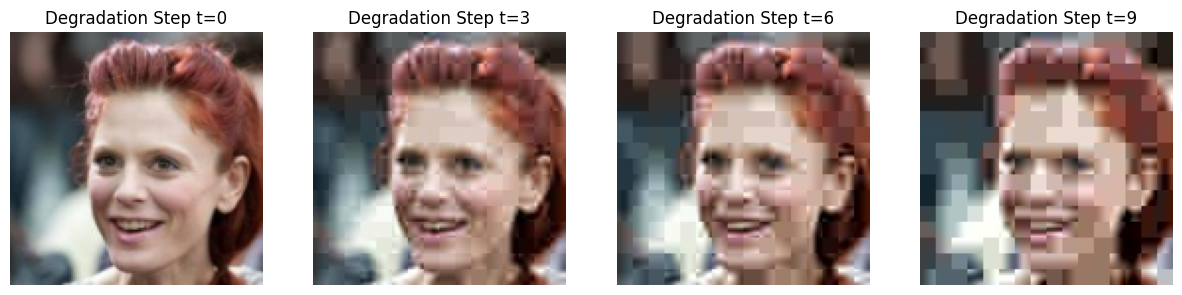

Reconstruction ...
Range of Image reconstructed before plotting: -2.249417304992676, 1.5709574222564697


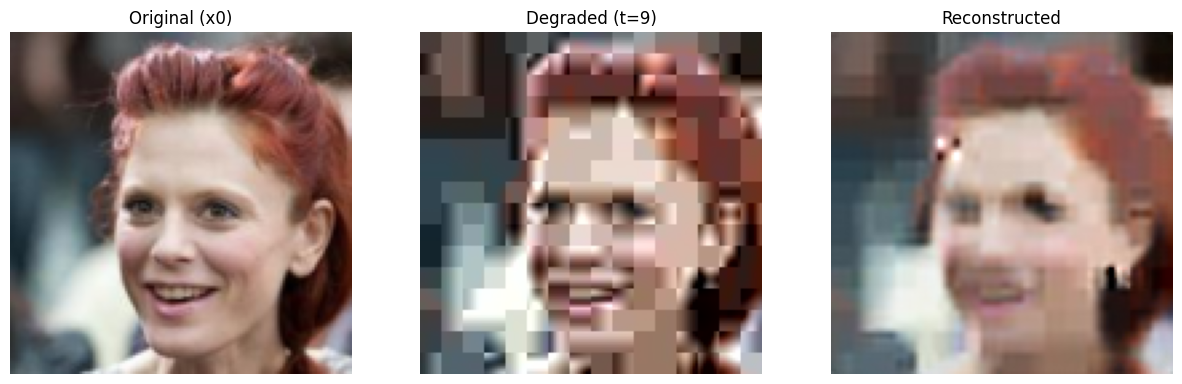

PSNR: 20.261699676513672
L1 Loss: 0.14425474405288696


In [ ]:
# --- PREPARATION ---
inner_model = diffusion

img_path = os.path.join(dataset_path, '000002.jpg')
x_0_pil = Image.open(img_path)     # taking first image of the batch

# Apply the same preprocessing as for training data
preprocess = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])
to_tensor = transforms.ToTensor()

x_0_processed = preprocess(x_0_pil)
x_0 = (to_tensor(x_0_processed) * 2) - 1 # Convert to tensor and normalize to [-1, 1]
x_0 = x_0.unsqueeze(0).to('cuda') # Add batch dimension and move to GPU

# visualization parameters
steps_to_show = [0, 3, 6, 9]
n_steps = len(steps_to_show)

# --- DEGRADATION ---
print("Degradation (DCT)...")
fig, axs = plt.subplots(1, n_steps, figsize=(15, 5))
for i, t in enumerate(steps_to_show):
    with torch.no_grad():
        x_t = inner_model.q_sample(x_0, torch.tensor([t], device='cuda'))

    # From [-1, 1] to [0, 1]
    print(f"Range of Image before plotting: {x_t.min()}, {x_t.max()}")
    img_vis = ((x_t.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy()
    axs[i].imshow(img_vis.clip(0, 1))
    axs[i].set_title(f"Degradation Step t={t}")
    axs[i].axis('off')
plt.show()


# --- RECONSTRUCTION ---
print("Reconstruction ...")

with torch.no_grad():
    xt, direct_recons,_img = inner_model.sample(batch_size=1, img=x_t)

    print(f"Range of Image reconstructed before plotting: {_img.min()}, {_img.max()}")
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Original Image
axs[0].imshow(((x_0.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[0].set_title("Original (x0)")

# Maximum degradation
axs[1].imshow(((xt.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[1].set_title("Degraded (t=9)")

# Reconstruction
axs[2].imshow(((_img.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[2].set_title("Reconstructed")

for ax in axs: ax.axis('off')
plt.show()

psnr = calculate_psnr(x_0,_img)
print(f"PSNR: {psnr}")

l1_loss = F.l1_loss(_img, x_0).item()
print(f"L1 Loss: {l1_loss}")

# Test

In [ ]:
if TEST:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    results_psnr = []
    best_results = []
    worst_results = []

    max_test_images = 500
    processed_images = 0

    print(f"Starting testing on max {max_test_images} images...")

    diffusion.eval()

    with torch.no_grad():
        for batch in test_loader:
            if processed_images >= max_test_images:
                print("dropping last batch")
                break

            gt_tensor_norm = batch.to(device)
            curr_batch_size = min(gt_tensor_norm.shape[0], max_test_images - processed_images)
            gt_tensor_norm = gt_tensor_norm[:curr_batch_size]

            _, _, restored_norm = diffusion.sample(batch_size=curr_batch_size, img=gt_tensor_norm)

            gt_01 = (gt_tensor_norm + 1).mul_(0.5)
            restored_01 = (restored_norm + 1).mul_(0.5).clamp_(0, 1)

            gt_cpu = gt_01.cpu()
            restored_cpu = restored_01.cpu()

            del gt_tensor_norm, restored_norm, gt_01, restored_01
            torch.cuda.empty_cache()

            for b in range(curr_batch_size):
                single_gt = gt_cpu[b:b+1]
                single_restored = restored_cpu[b:b+1]

                psnr = calculate_psnr(single_gt, single_restored)
                results_psnr.append(psnr)

                current_res = {
                    'psnr': psnr,
                    'index': processed_images,
                    'restored': single_restored,
                    'gt': single_gt
                }

                # Best 5
                if len(best_results) < 5 or psnr > best_results[-1]['psnr']:
                    best_results.append(current_res)
                    best_results.sort(key=lambda x: x['psnr'], reverse=True)
                    best_results = best_results[:5]

                # Worst 5
                if len(worst_results) < 5 or psnr < worst_results[-1]['psnr']:
                    worst_results.append(current_res)
                    worst_results.sort(key=lambda x: x['psnr'])
                    worst_results = worst_results[:5]

                processed_images += 1
                print(f"Processing {processed_images}/{max_test_images} - PSNR: {psnr:.2f} dB")

            del gt_cpu, restored_cpu
            gc.collect()

    avg_psnr = sum(results_psnr) / len(results_psnr)
    print(f"\nTest completed")
    print(f"Mean PSNR over {processed_images} images: {avg_psnr:.2f} dB")
else:
    print("Skipping testing")

Skipping testing


In [ ]:
for batch in test_loader:
    gt_tensor_norm = batch.to(device)
    curr_batch_size = min(gt_tensor_norm.shape[0], max_test_images - processed_images)
    print(f"batch shape: {gt_tensor_norm.shape}")
    print(f"curr_batch_size: {curr_batch_size}")
    print(f"processed_images: {processed_images}")
    break

In [ ]:
print(f"Media PSNR: {np.mean(results_psnr):.2f}")

worst_5_psnr_values = [f"{item['psnr']:.2f}" for item in worst_results[:5]]
print(f"Worst 5 PSNR: {', '.join(worst_5_psnr_values)}")

best_5_psnr_values = [f"{item['psnr']:.2f}" for item in best_results[:5]]
print(f"Best 5 PSNR: {', '.join(best_5_psnr_values)}")

In [ ]:
# BEST
if TEST:
    b = best_results[0]

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Originale")
    plt.imshow(b['gt'].squeeze().permute(1, 2, 0).cpu().detach().clamp(0, 1))

    # Normalize b['gt'] from [0, 1] to [-1, 1] before passing to jpeg_degradation
    normalized_gt = (b['gt'] * 2) - 1
    b['degraded'] = jpeg_degradation(normalized_gt, 9)

    plt.subplot(1, 3, 2)
    plt.title(f"Degradata (Input)")
    # Denormalize for display: from [-1, 1] back to [0, 1]
    img_display = ((b['degraded'].squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().detach().clamp(0, 1)
    plt.imshow(img_display)

    plt.subplot(1, 3, 3)
    plt.title(f"Restaurata (Output) - PSNR: {b['psnr']:.2f}")
    plt.imshow(b['restored'].squeeze().permute(1, 2, 0).cpu().detach().clamp(0, 1))

    plt.show()

In [ ]:
# WORST
if TEST:
    w = worst_results[0]

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title(f"Originale")
    plt.imshow(w['gt'].squeeze().permute(1, 2, 0).cpu().detach().clamp(0, 1))

    w['degraded'] = jpeg_degradation(w['gt'], 9)

    plt.subplot(1, 3, 2)
    plt.title(f"Degradata (Input)")
    plt.imshow((w['degraded'].squeeze()).permute(1, 2, 0).cpu().detach().clamp(0, 1))

    plt.subplot(1, 3, 3)
    plt.title(f"Restaurata (Output) - PSNR: {w['psnr']:.2f}")
    plt.imshow(w['restored'].squeeze().permute(1, 2, 0).cpu().detach().clamp(0, 1))
    plt.show()

In [ ]:
import torch.nn.functional as F

# Ensure inner_model refers to the DummyWrapper instance
inner_model = diffusion

# If x_0 is not defined, load an example image
if 'x_0' not in locals():
    img_path = '/content/raw_data/img_align_celeba/000002.jpg'
    x_0_pil = Image.open(img_path).convert('RGB')
    preprocess = transforms.Compose([
        transforms.CenterCrop(178),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
    ])
    to_tensor = transforms.ToTensor()

    x_0_processed = preprocess(x_0_pil)
    x_0 = (to_tensor(x_0_processed) * 2) - 1 # Convert to tensor and normalize to [-1, 1]
    x_0 = x_0.unsqueeze(0).to('cuda') # Add batch dimension and move to GPU

# Define the step for this test
t_test = 3

# --- DEGRADATION ---
print(f"Degradation (DCT) at step {t_test}...")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

with torch.no_grad():
    x_t_degraded = inner_model.q_sample(x_0, torch.tensor([t_test], device='cuda'))

# Original Image
axs[0].imshow(((x_0.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[0].set_title("Original (x0)")
axs[0].axis('off')

# Degraded Image
img_degraded_vis = ((x_t_degraded.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy()
axs[1].imshow(img_degraded_vis.clip(0, 1))
axs[1].set_title(f"Degradation Step t={t_test}")
axs[1].axis('off')

plt.tight_layout()
plt.show()

# --- RECONSTRUCTION ---
print("Reconstruction ...")

with torch.no_grad():
    # .sample() returns (degraded_image_at_t_max, direct_reconstruction, final_reconstruction)
    # We are interested in the final_reconstruction here.
    _, _, reconstructed_img = inner_model.sample(batch_size=1, img=x_t_degraded, t=t_test)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Original Image
axs[0].imshow(((x_0.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[0].set_title("Original (x0)")

# Degraded at t_test
axs[1].imshow(((x_t_degraded.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[1].set_title(f"Degraded (t={t_test})")

# Reconstruction
axs[2].imshow(((reconstructed_img.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[2].set_title("Reconstructed")

for ax in axs: ax.axis('off')
plt.show()

psnr = calculate_psnr(x_0, reconstructed_img)
print(f"PSNR (t={t_test}): {psnr:.2f}")

l1_loss = F.l1_loss(reconstructed_img, x_0).item()
print(f"L1 Loss (t={t_test}): {l1_loss:.4f}")